# sklearn GP to BoTorch GP Hyperparameter Transfer

This notebook compares three models on the same data and EI grid:

- sklearn GP (`Constant * RBF + WhiteKernel`)
- BoTorch GP (hyperparameters optimized with BoTorch)
- BoTorch GP (hyperparameters copied from trained sklearn GP, **no BoTorch optimization**)

The fixed BoTorch path is the test requested: if sklearn params are passed, BoTorch skips fitting.

In [1]:
import numpy as np
from scipy.stats import norm
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import ConstantKernel, RBF, WhiteKernel

try:
    import torch
    from botorch.acquisition import LogExpectedImprovement
    from botorch.fit import fit_gpytorch_mll
    from botorch.models import SingleTaskGP
    from botorch.models.transforms.outcome import Standardize
    from gpytorch.constraints import Interval
    from gpytorch.kernels import RBFKernel, ScaleKernel
    from gpytorch.likelihoods import GaussianLikelihood
    from gpytorch.mlls import ExactMarginalLogLikelihood
except Exception as exc:
    raise ImportError(
        "Missing BoTorch deps. Install torch, botorch, gpytorch in this kernel first. "
        f"Details: {exc}"
    )

#import tamubo.exactbo as ebo


In [2]:
torch.cuda.is_available()

True

In [3]:
print(torch.version.cuda)

13.0


In [33]:
np.random.seed(0)
torch.manual_seed(0)

def objective(X: np.ndarray) -> np.ndarray:
    X = np.asarray(X, dtype=float)
    if X.ndim == 1:
        X = X.reshape(1, -1)
    x, y = X[:, 0], X[:, 1]
    alpha = 0.1
    A = np.array([4.0, 3.0, 2.0], dtype=float)
    B = np.array([0.08, 0.05, 0.02], dtype=float)
    C = np.array([[0.9, 0.3], [0.1, 0.8], [0.6, 0.7]], dtype=float)
    D = 2.0
    val = alpha * (x**2 + y**2)
    for Ai, Bi, (xi, yi) in zip(A, B, C):
        r2 = (x - xi) ** 2 + (y - yi) ** 2
        val -= Ai * np.exp(-r2 / Bi)
    return val + D

bounds_np = np.array([[0.0, 1.0], [0.0, 1.0]], dtype=float)
X_train = np.array(
    [
        [0.25, 0.25],
        [0.25, 0.75],
        [0.75, 0.25],
        [0.75, 0.75],
        [0.81, 0.25],
        [0.97, 0.25],
#        [0.35, 0.45],
#        [0.65, 0.55],
    ],
    dtype=float,
)
y_train = objective(X_train)
dim = X_train.shape[1]

print(f"X_train shape: {X_train.shape}, y_train shape: {y_train.shape}")
print(f"best observed y: {y_train.min():.6f}")

X_train shape: (6, 2), y_train shape: (6,)
best observed y: -1.546257


In [34]:
def extract_sklearn_params(gp: GaussianProcessRegressor) -> dict:
    """Extract sigma_f, sigma_n, and lengthscales from sklearn kernel_=Const*RBF + White."""
    k = gp.kernel_
    sigma_f2 = float(k.k1.k1.constant_value)
    sigma_n2 = float(k.k2.noise_level)
    lengthscales = np.asarray(k.k1.k2.length_scale, dtype=float).reshape(-1)
    return {
        "sigma_f2": sigma_f2,
        "sigma_n2": sigma_n2,
        "lengthscales": lengthscales,
    }


def build_botorch_gp(
    X_train_np: np.ndarray,
    y_train_np: np.ndarray,
    *,
    fixed_params: dict | None = None,
    optimize_hypers: bool = True,
    device: str | torch.device = "cpu",
):
    """Build BoTorch GP. If fixed_params provided, skip BoTorch hyperparameter optimization."""
    dev = torch.device(device)
    X_t = torch.as_tensor(X_train_np, dtype=torch.double, device=dev)
    Y_t = torch.as_tensor(y_train_np.reshape(-1, 1), dtype=torch.double, device=dev)
    d = X_train_np.shape[1]
    n = X_train_np.shape[0]
    ddof_correction = (n-1)/n

    covar_module = ScaleKernel(
        RBFKernel(
            ard_num_dims=d,
            lengthscale_constraint=Interval(1e-2, 1e2),
        ),
        outputscale_constraint=Interval(1e-2, 1e3),
    )
    likelihood = GaussianLikelihood(noise_constraint=Interval(1e-10, 1e1))

    model = SingleTaskGP(
        train_X=X_t,
        train_Y=Y_t,
        covar_module=covar_module,
        likelihood=likelihood,
        outcome_transform=Standardize(m=1),
    )

    # Default initial values, matching sklearn defaults.
    model.covar_module.outputscale = 1.0
    model.covar_module.base_kernel.lengthscale = 0.2
    model.likelihood.noise = 1e-3

    if fixed_params is not None:
        ls_t = torch.as_tensor(fixed_params["lengthscales"], dtype=torch.double, device=dev).reshape(1, -1)
        model.covar_module.outputscale = float(fixed_params["sigma_f2"]) * ddof_correction
        model.covar_module.base_kernel.lengthscale = ls_t
        model.likelihood.noise = float(fixed_params["sigma_n2"]) * ddof_correction
        optimize_hypers = False

    if optimize_hypers:
        mll = ExactMarginalLogLikelihood(model.likelihood, model)
        fit_gpytorch_mll(mll)
    else:
        # Freeze so accidental optimizer calls cannot change hyperparameters.
        for p in model.parameters():
            p.requires_grad_(False)

    model.eval()
    return model


def print_botorch_params(label: str, model):
    print(label)
    print("  sigma_f^2:", float(model.covar_module.outputscale.detach().cpu()), ", sigma_n^2:", float(model.likelihood.noise.detach().cpu()))
    print("  lengthscales:", model.covar_module.base_kernel.lengthscale.detach().cpu().numpy().ravel())


In [35]:
# 1) Train sklearn GP
sk_kernel = (
    ConstantKernel(1.0, (1e-2, 1e3))
    * RBF(length_scale=np.full(dim, 0.2), length_scale_bounds=(1e-2, 1e2))
    + WhiteKernel(noise_level=1e-3, noise_level_bounds=(1e-10, 1e1))
)
gp_sklearn = GaussianProcessRegressor(kernel=sk_kernel, alpha=0, normalize_y=True)
gp_sklearn.fit(X_train, y_train)
print("sklearn learned kernel:")
print(gp_sklearn.kernel_)

sk_params = extract_sklearn_params(gp_sklearn)
print("\nExtracted sklearn params:")
print("  sigma_f^2:", sk_params["sigma_f2"], ", sigma_n^2:", sk_params["sigma_n2"])
print("  lengthscales:", sk_params["lengthscales"])

# 2) Build BoTorch model with optimized hyperparameters (reference)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
gp_botorch_optimized = build_botorch_gp(
    X_train,
    y_train,
    device=device,
)
print_botorch_params("\nBoTorch optimized params:", gp_botorch_optimized)

# 3) Build BoTorch model with sklearn hyperparameters copied in (no BoTorch optimization)
gp_botorch_fixed = build_botorch_gp(
    X_train,
    y_train,
    fixed_params=sk_params,
    device=device,
)
print_botorch_params("\nBoTorch fixed-from-sklearn params:", gp_botorch_fixed)


/usr/local/lib/python3.12/dist-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 1 of parameter k1__k2__length_scale is close to the specified lower bound 0.01. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


sklearn learned kernel:
0.989**2 * RBF(length_scale=[0.304, 0.01]) + WhiteKernel(noise_level=0.0193)

Extracted sklearn params:
  sigma_f^2: 0.9785884518993827 , sigma_n^2: 0.019317445714849578
  lengthscales: [0.30406846 0.01      ]

BoTorch optimized params:
  sigma_f^2: 0.6935905054739931 , sigma_n^2: 0.008508579659305633
  lengthscales: [0.24004921 0.01000006]

BoTorch fixed-from-sklearn params:
  sigma_f^2: 0.8154903650283812 , sigma_n^2: 0.01609787158668041
  lengthscales: [0.30406846 0.01      ]


In [104]:
# Shared EI grid comparison
resolution = 101
x1 = np.linspace(bounds_np[0, 0], bounds_np[0, 1], resolution)
x2 = np.linspace(bounds_np[1, 0], bounds_np[1, 1], resolution)
mesh = np.meshgrid(x1, x2, indexing="ij")
grid_np = np.stack([mesh[0].reshape(-1), mesh[1].reshape(-1)], axis=1)
grid_t = torch.as_tensor(grid_np, dtype=torch.double, device=device)

y_best = float(y_train.min())

# sklearn EI
mu_sk, sigma_sk = gp_sklearn.predict(grid_np, return_std=True)
y_train_std = gp_sklearn._y_train_std
sigma_n2_raw = gp_sklearn.kernel_.k2.noise_level * y_train_std**2
sigma_sk_lat = np.sqrt(np.clip(sigma_sk**2 - sigma_n2_raw, 1e-12, None))
z = (y_best - mu_sk) / sigma_sk_lat
ei_sk = (y_best - mu_sk) * norm.cdf(z) + sigma_sk_lat * norm.pdf(z)

def botorch_logei_to_ei(model, X_t, y_best_value: float) -> np.ndarray:
    acqf = LogExpectedImprovement(model=model, best_f=y_best_value, maximize=False)
    with torch.no_grad():
        log_ei = acqf(X_t.unsqueeze(-2)).detach().cpu().numpy().ravel()
    return np.exp(log_ei)

ei_bt_opt = botorch_logei_to_ei(gp_botorch_optimized, grid_t, y_best)
ei_bt_fixed = botorch_logei_to_ei(gp_botorch_fixed, grid_t, y_best)

def summarize_vs_sklearn(label: str, ei_candidate: np.ndarray):
    abs_diff = np.abs(ei_sk - ei_candidate)
    corr = np.corrcoef(ei_sk, ei_candidate)[0, 1]
    idx_sk = int(np.argmax(ei_sk))
    idx_c = int(np.argmax(ei_candidate))
    print(label)
    print("  sklearn best x:", grid_np[idx_sk], "EI:", float(ei_sk[idx_sk]))
    print("  candidate best x:", grid_np[idx_c], "EI:", float(ei_candidate[idx_c]))
    print("  max |EI_sklearn - EI_candidate|:", float(abs_diff.max()))
    print("  mean |EI_sklearn - EI_candidate|:", float(abs_diff.mean()))
    print("  corr(EI_sklearn, EI_candidate):", float(corr))
    print("  argmax same point?:", bool(idx_sk == idx_c))

summarize_vs_sklearn("BoTorch optimized vs sklearn", ei_bt_opt)
print()
summarize_vs_sklearn("BoTorch fixed-from-sklearn vs sklearn", ei_bt_fixed)

BoTorch optimized vs sklearn
  sklearn best x: [0.95 0.26] EI: 0.19795729205823132
  candidate best x: [0.91 0.24] EI: 0.12174037369338692
  max |EI_sklearn - EI_candidate|: 0.09224282430621203
  mean |EI_sklearn - EI_candidate|: 0.06115761662221051
  corr(EI_sklearn, EI_candidate): 0.7871812474065372
  argmax same point?: False

BoTorch fixed-from-sklearn vs sklearn
  sklearn best x: [0.95 0.26] EI: 0.19795729205823132
  candidate best x: [0.95 0.24] EI: 0.19795729860248137
  max |EI_sklearn - EI_candidate|: 1.7430908549886936e-08
  mean |EI_sklearn - EI_candidate|: 2.0268175748908517e-09
  corr(EI_sklearn, EI_candidate): 1.0
  argmax same point?: False


In [105]:
with torch.no_grad():
    post_opt = gp_botorch_optimized.posterior(grid_t)
    post_fixed = gp_botorch_fixed.posterior(grid_t)

mu_bt_opt, sigma_bt_opt = post_opt.mean.detach().cpu().numpy().ravel(), post_opt.variance.sqrt().detach().cpu().numpy().ravel()
mu_bt_fixed, sigma_bt_fixed = post_fixed.mean.detach().cpu().numpy().ravel(), post_fixed.variance.sqrt().detach().cpu().numpy().ravel()

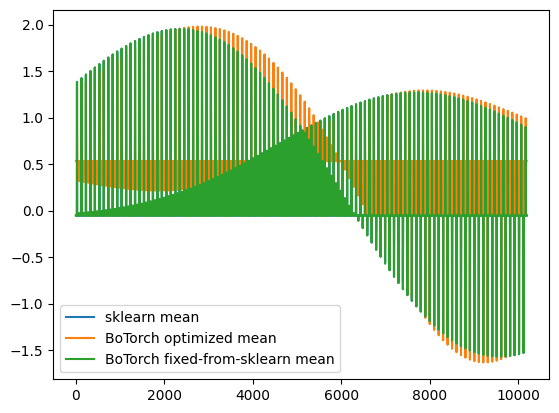

In [106]:
import matplotlib.pyplot as plt
plt.plot(mu_sk, label="sklearn mean")
plt.plot(mu_bt_opt, label="BoTorch optimized mean")
plt.plot(mu_bt_fixed, label="BoTorch fixed-from-sklearn mean")
plt.legend()

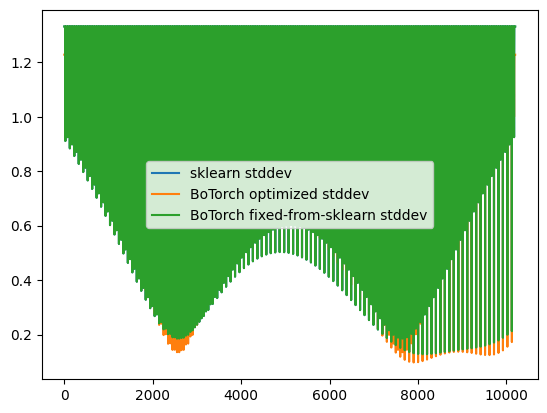

In [107]:
plt.plot(sigma_sk_lat, label="sklearn stddev")
plt.plot(sigma_bt_opt, label="BoTorch optimized stddev")
plt.plot(sigma_bt_fixed, label="BoTorch fixed-from-sklearn stddev")
plt.legend()

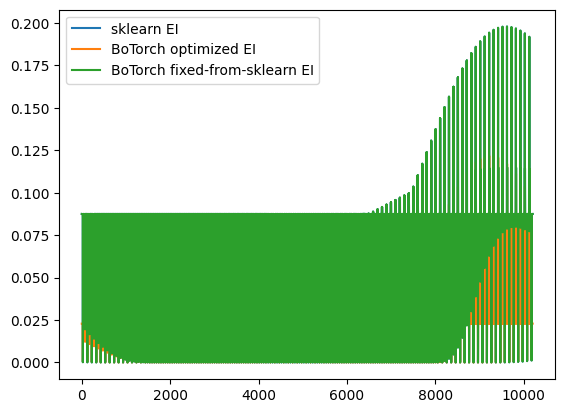

In [108]:
plt.plot(ei_sk, label="sklearn EI")
plt.plot(ei_bt_opt, label="BoTorch optimized EI")
plt.plot(ei_bt_fixed, label="BoTorch fixed-from-sklearn EI")
plt.legend()

In [109]:
np.allclose(mu_sk, mu_bt_fixed), np.allclose(sigma_sk_lat, sigma_bt_fixed), np.allclose(ei_sk, ei_bt_fixed)

(True, True, True)

In [110]:
np.corrcoef(mu_sk, mu_bt_fixed)[0, 1], np.corrcoef(sigma_sk_lat, sigma_bt_fixed)[0, 1], np.corrcoef(ei_sk, ei_bt_fixed)[0, 1]

(np.float64(1.0), np.float64(1.0), np.float64(1.0))

In [90]:
ei_bt_fixed[~np.isclose(ei_bt_fixed, ei_sk)]

array([], dtype=float64)

In [91]:
ei_sk[~np.isclose(ei_bt_fixed, ei_sk)]

array([], dtype=float64)

In [92]:
mu_bt_fixed[~np.isclose(ei_bt_fixed, ei_sk)]

array([], dtype=float64)

In [93]:
mu_sk[~np.isclose(ei_bt_fixed, ei_sk)]

array([], dtype=float64)

In [94]:
sigma_bt_fixed[~np.isclose(ei_bt_fixed, ei_sk)]

array([], dtype=float64)

In [95]:
sigma_sk_lat[~np.isclose(ei_bt_fixed, ei_sk)]

array([], dtype=float64)

In [97]:
sigma_sk_lat.min()

np.float64(0.127540462311444)

In [98]:
y_best

-1.5462569310631054

In [99]:
np.max(ei_sk - ei_bt_fixed)

np.float64(-2.7749515124957297e-87)

In [100]:
device.type

'cuda'

In [101]:
ei_bt_fixed.min()

np.float64(5.567696379127625e-82)

In [103]:
ei_sk.min()

np.float64(5.5676686296125e-82)